---
title: "How much battery model do you actually need?"
description: "Marquis et al.'s asymptotic reduction of the Doyle–Fuller–Newman model — the SPM and the SPMe — applied to the gallery's own 1993 cell, with the error scaling the asymptotics promise measured against the full model."
categories: [sec:J, struct:S8, struct:S10, struct:S3, tier:T1, data:tier6, phase:liquid-solid]
date: 2026-07-31
---

# How much battery model do you actually need?

**Catalog ID:** `J3.5` · **Structures:** `S8` (coupled multi-phase transport
with electroneutrality), `S10` (porous electrode with a distributed interfacial
reaction), reduced towards `S3` · **Tier:** T1

The full pseudo-two-dimensional battery model
([`J3.4`](../J3.4-doyle-fuller-newman/)) is too expensive for the places most
battery models actually run — battery management systems, pack simulations,
parameter estimation loops. The industry answer is the *single particle model*
(SPM) and its electrolyte-corrected extension (SPMe). This page builds both,
not as ad-hoc simplifications, but as the leading- and first-order terms of a
systematic asymptotic expansion — and then measures whether the errors shrink
at the rate the asymptotics promise.

## Background

The Doyle–Fuller–Newman (DFN) model couples salt transport, two potentials and
particle-scale diffusion through a nonlinear reaction distributed over the
electrode. Most of the time, most of that machinery is idle: at low current the
electrolyte is nearly uniform, the potentials are nearly flat, and every
particle in the electrode does the same thing. The SPM is what is left — one
representative particle per electrode and an algebraic voltage expression.

For twenty years the literature extended the SPM with electrolyte corrections
by ad-hoc argument, each version keeping a different subset of terms. Marquis,
Sulzer, Timms, Please and Chapman (2019) replaced the guesswork with an
asymptotic derivation: expand the DFN model in $\mathcal{C}_e$, the ratio of
the electrolyte transport timescale to the discharge timescale, in the
distinguished limit where the ohmic drops are comparably small. At leading
order the SPM falls out; at first order, one *linear* PDE for the electrolyte
correction plus an algebraic voltage correction — the SPMe. The derivation
buys two things no ad-hoc model has: an *a-priori* applicability test
(their Table VI), and a predicted error scaling — the SPM voltage error is
$O(\mathcal{C}_e)$ and the SPMe error $O(\mathcal{C}_e^2)$.

This page applies their derivation to the cell the DFN model was born on: the
Li | separator | TiS$_2$ half-cell of Doyle, Fuller & Newman (1993), exactly as
implemented and staged on [`J3.4`](../J3.4-doyle-fuller-newman/). The full
model, its parameter set and its reductions then live in one place, and the
reduced models can be tested against a full solution whose own fidelity the
gallery has already established.

**Nothing on this page touches a measurement.** The J3.4 reference is a
reproduction of a published simulation (its Figure 2 has no experimental
points), and every comparison here is reduced-model against full-model. This
page is tier 6 twice over, and says so.

## The published model

Marquis et al. start from the DFN model (their Eqs. 1), nondimensionalise
(their Tables II–III), and take the limit $\mathcal{C}_e \to 0$ with

$$
\mathcal{C}_e = \frac{\tau_e}{\tau_d}
= \frac{I\,L^2}{D_e\,F\,c_{\rm cap}\,\delta_{\rm cap}} \ll 1 ,
\qquad
\bar\sigma_k = \frac{RT/F}{I L/\sigma_k} \gg 1 ,
\qquad
\hat\kappa_e = \frac{RT/F}{I L/\kappa_e} \gg 1 ,
$$

in the distinguished limit $\bar\sigma_k \mathcal{C}_e,\ \hat\kappa_e
\mathcal{C}_e = O(1)$. Here $\tau_e$ is the electrolyte diffusion time over the
whole cell of thickness $L$ and $\tau_d$ the discharge time set by the
electrode capacity.

**Leading order — the SPM** (their Eqs. 20). The electrolyte concentration is
uniform, both potentials are flat, and the transfer current is uniform in each
electrode, so every particle behaves identically. What remains is diffusion in
one representative particle per electrode with a known surface flux, and a
voltage that is open-circuit potential plus reaction overpotentials.

**First order — the SPMe** (their Eqs. 40, dimensional summary in their
Eqs. 48). The corrections are: one linear diffusion PDE for the electrolyte
perturbation $c^1_e(x,t)$, forced by the (known, leading-order) migration flux;
and four algebraic voltage terms — a concentration overpotential
$2(RT/F)(1-t^0_+)\,\Delta \bar c_e/c_{e,\rm typ}$, an electrolyte ohmic drop
$-I\,(\frac{L_n}{3\kappa_n^{\rm eff}}+\frac{L_s}{\kappa_s^{\rm eff}}
+\frac{L_p}{3\kappa_p^{\rm eff}})$, matrix ohmic drops, and a correction to the
exchange-current densities averaged over each electrode. Their key step is that
every term is **electrode-averaged**, not pointwise: averaging the exact
voltage identity (their Eq. 10) over all current paths is what makes the
expression correct to $O(\mathcal{C}_e^2)$, and it is precisely the step the
ad-hoc models skip. Their Figure 7 shows the canonical SPMe outperforming
every ad-hoc variant at every C-rate — by an order of magnitude against two
of the three.

The paper also states the price (their Eq. 49): the model error at a given
time is $O(\mathcal{C}_e^2)$, with a prefactor that blows up where the OCV is
strongly curved. And it gives the conditions to check *before* trusting the
reduction (their Table VI) — checked below for the Doyle cell.

### The same reduction for the 1993 half-cell

The J3.4 cell is Li foil | separator ($\epsilon=1$) | porous TiS$_2$ cathode,
with the lithium foil a *plane*, so only the cathode needs the
electrode-averaging step; the anode terms are genuinely pointwise. Following
the paper's path argument (their Eq. 6) from foil to collector and averaging
uniformly over the reaction point $x_p$ in the cathode:

$$
V \;=\; \underbrace{\overline{\Phi_1(x_p)-\Phi_2(x_p)}}_{\text{cathode kinetics + OCP}}
\;+\; \underbrace{\overline{\Phi_2(x_p)-\Phi_2(0)}}_{\text{electrolyte}}
\;-\; \underbrace{\eta_{s1}}_{\text{foil kinetics}}
\;-\; \underbrace{\frac{I\delta_c}{2\sigma}}_{\text{matrix}} .
$$

**Leading order (SPM).** With $S_c \approx 10^{-4}$ (established on J3.4 from
the paper's own Eq. 26), diffusion *inside* the particle is negligible too, so
the entire solid state is one number: the utilisation
$u(t) = u_0 + I t/(F(1-\epsilon)c_T\delta_c)$ — exact coulomb counting, which
charge conservation makes exact for the full model as well (checked below).
The uniform transfer current is $i = -I/(a\delta_c)$, and Eq. 17 of Doyle et
al. inverts in closed form: with
$B = i/[Fk_2(c_{\max}-c)^{\alpha}c^{\alpha}]$,

$$
c_s z^2 - B z - (c_T-c_s) = 0, \qquad
\Phi_1-\Phi_2 = U' (c_s) + \frac{RT}{\alpha F}\ln z ,
$$

taking the positive root $z$. At $I\to0$ this reduces exactly to the Eq. 16
open-circuit potential. The SPM voltage is therefore **purely algebraic**:

$$
V^0(u, I) = U'(uc_T) + \frac{RT}{\alpha F}\ln z\big|_{c=c_0}
- \eta_{s1}(I, c_0) - \frac{I\delta_c}{2\sigma}.
$$

**First order (SPMe).** The electrolyte perturbation
$\tilde c = c - c_0$ satisfies

$$
\epsilon(x)\frac{\partial \tilde c}{\partial t}
= \frac{\partial}{\partial x}\Big(\epsilon^{1/2} D
\frac{\partial \tilde c}{\partial x}\Big) + s(x),
\qquad
s = \begin{cases} 0 & \text{separator} \\
-\dfrac{(1-t^0_+)I}{F\delta_c} & \text{cathode}, \end{cases}
$$

with zero *total* salt flux at both ends (the known migration flux enters
through the boundary condition), and the voltage becomes

$$
V^1 = U'(uc_T) + \frac{RT}{\alpha F}\ln \bar z
\;-\; I\Big(\frac{\delta_s}{\kappa} + \frac{\delta_c}{3\kappa\epsilon^{3/2}}\Big)
\;+\; \frac{2RT}{F}(1-t^0_+)\frac{\langle\tilde c\rangle_c - \tilde c(0)}{c_0}
\;-\; \eta_{s1}\big(I, c(0)\big) - \frac{I\delta_c}{2\sigma},
$$

where $\bar z$ uses the exchange-current prefactor averaged over the cathode
(their Eqs. 48n–o), $\langle\tilde c\rangle_c$ is the plain average over the
cathode, and $\tilde c(0)$ the value at the foil. The $\delta_c/3$ in the ohmic
term is the electrode-averaging of the linearly decaying current — the
half-cell twin of their Eq. 48p.

Because the discharge here is galvanostatic and the forcing constant, the PDE
also has a **closed-form quasi-steady solution** — piecewise quadratic in $x$
— which is Marquis et al.'s steady-state variant SPMe(S) and doubles as an
exact solution to test the pymrm operators against.

## Parameters and assumptions

**Every physical parameter comes from the J3.4 page**, loaded from its
reviewed dataset — the Doyle (1993) Tables I–II values read off 600 dpi
renders, with the Eq. 16/20 open-circuit constants that J3.4 validated to
3.3 mV against the paper's own plotted curve. Nothing is re-derived here, and
nothing is fitted.

Three inherited choices matter, all settled on J3.4 and kept **identical** in
the full model and the reductions, because a reduction must be compared
against the model it was derived from:

1. **The conductivity** $\kappa$ is J3.4's reconstruction — a constant
   recovered from the paper's own dimensionless groups (Eq. 28; the Eq. 29
   route agrees to 19 %). The reductions use the same constant.
2. **The salt-flux Bruggeman exponent** is $D\epsilon^{1/2}$ and the
   conductivity's is $\kappa\epsilon^{3/2}$, as J3.4 established from the
   paper's own Figure 3.
3. **The factor 2 in the concentration term** of the current equation
   (thermodynamics of a 1:1 salt) is kept, as on J3.4.

Reduction-specific assumptions, both first-order consistent: the transference
number is evaluated at $c_0$ in the SPMe (the DFN lets it vary with $c$), and
the BV concentration prefactors are linearised through the electrode average.

**What a shared parameter error is invisible to.** Using one parameter set for
both models is what makes the measured error the *reduction's* error — and it
is exactly what stops this page from testing the parameters. $U_{\rm ocp}$,
$k_2$, $\sigma$, $i_{0,1}$ and above all $\kappa$ enter the full model and the
reductions *identically*, so an error in any of them cancels to first order in
every comparison here. $\kappa$ is the one that matters, because it is the
reconstructed input: J3.4's two published routes to it disagree by 19 %, and it
appears in the DFN's face conductivities and in the SPMe's
$-I(\delta_s/\kappa + \delta_c/3\kappa\epsilon^{3/2})$, where the two largely
cancel. The Validation section measures how much of that 19 % survives into the
comparison: it moves both discharge curves by 0.8 mV together and the measured
SPMe error by 9 %, against the 9.8× that a 10 % error in the reduction's *own*
ohmic coefficient produces. That is the honest statement of both the strength
and the blindness of a model-vs-model page.

One honesty note before any number: because this cell's $\kappa$ and $D$ are
*constants*, the SPMe's ohmic and diffusive corrections have exactly the right
functional form, so the SPMe will look somewhat better here than it can on a
cell with concentration-dependent properties (as in Marquis et al.'s own
comparison, where $\kappa_e(c_e)$ varies). The error that remains is the real
asymptotic truncation error — which is exactly what this page wants to
measure — but the absolute mV numbers should not be read across to other
chemistries.

In [1]:
try:
    import pymrm
except ImportError:
    %pip install -q pymrm pyyaml

In [2]:
import sys, urllib.request
from pathlib import Path

if not any("shared" in p for p in sys.path):
    local = Path.cwd()
    for _ in range(4):
        if (local / "shared" / "gallery_utils.py").is_file():
            sys.path.insert(0, str(local / "shared")); break
        local = local.parent
    else:
        url = ("https://raw.githubusercontent.com/computational-chemical-engineering/"
               "pymrm-gallery/main/shared/gallery_utils.py")
        urllib.request.urlretrieve(url, "gallery_utils.py")
        sys.path.insert(0, ".")

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import splu, MatrixRankWarning
from pymrm import construct_grad, construct_div, NumJac, newton, stencil_block_diagonals
from gallery_utils import load_data, load_meta, cite_data, report_agreement

warnings.filterwarnings("ignore", category=MatrixRankWarning)
PAGE = "J3.5-single-particle-model"
PAGE_J34 = "J3.4-doyle-fuller-newman"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

R_GAS, F_CONST = 8.3143, 96487.0     # as used on J3.4 (Doyle-era constants)

## The data

Three datasets, with sharply different roles.

**J3.4's `doyle-fuller-newman-1993-parameters.csv`** (loaded cross-page) is
the *only* source of physical inputs. It is the maintainer-reviewed Doyle 1993
parameter set; its provenance and its one reconstructed input are documented on
the J3.4 page.

**`marquis-2019-table1-parameters.csv`** is Marquis et al.'s Table I — their
graphite | LiPF$_6$ | LCO parameter set. It is **not used to run any model
here**, because the paper prints the numbers but *not* the functional forms
$U_n(c)$, $U_p(c)$, $D_e(c_e)$, $\kappa_e(c_e)$ that go with them — for those
it cites Newman's DUALFOIL and Moura's fastDFN codes. That puts a full re-run
of their cell out of reach of the printed paper, which is why the validation
below reproduces their *derived tables* and their *error scaling* rather than
their Table IV. This table feeds exactly one thing: the arithmetic
reproduction of their Tables II and III.

**`marquis-2019-stated-results.csv`** is every derived number the paper
prints: the six timescales of Table II, the dimensionless parameters of
Table III, the ten RMS voltage errors of Table IV (their cell — context only),
and one in-text value of $\mathcal{C}_e$ that turns out to disagree with their
own Table III.

In [3]:
par = load_data("doyle-fuller-newman-1993-parameters.csv", page=PAGE_J34)
dstat = load_data("doyle-fuller-newman-1993-stated-results.csv", page=PAGE_J34)
mq1 = load_data("marquis-2019-table1-parameters.csv", page=PAGE)
mqs = load_data("marquis-2019-stated-results.csv", page=PAGE)
mq1_meta = load_meta("marquis-2019-table1-parameters.csv", page=PAGE)

P = {r.symbol: float(r.value) for r in par.itertuples()}
T = P["T"]
RTF = R_GAS * T / F_CONST
f_RT = 1.0 / RTF
C_T = P["c_T"]
eps_c, dc, ds = P["epsilon"], P["delta_c"], P["delta_s"]
alpha = P["alpha_a"]
sigma = P["sigma"]
a_spec = 3.0 * (1 - eps_c) / P["R_s"]
T_FULL = (1 - eps_c) * C_T * dc * F_CONST      # discharge time x current density

M = {r.symbol: float(r.value) for r in mq1.itertuples()}
print(f"J3.4 parameter set: {len(par)} values (see the J3.4 page for provenance)")
print(f"Marquis Table I:    {len(mq1)} values;  stated results: {len(mqs)} values")
print(cite_data(mq1_meta))

J3.4 parameter set: 25 values (see the J3.4 page for provenance)
Marquis Table I:    32 values;  stated results: 32 values
Marquis, S. G.; Sulzer, V.; Timms, R.; Please, C. P.; Chapman, S. J. (2019) — Journal of the Electrochemical Society 166(15) A3693-A3706 — doi:10.1149/2.0341915jes — table


### First check: the paper's own arithmetic, reproduced

Tables II and III are pure arithmetic on Table I. Recomputing all twenty-one
derived values (six timescales, fifteen dimensionless groups; $\gamma_n=1$ is
definitional and skipped) tests every Table I entry that enters any
dimensionless group, and tests that the definitions used below
($\mathcal{C}_e$, $\hat\kappa_e$, $\bar\sigma_k$, the timescales) are the
paper's. Two findings, printed rather than silently fixed:

* the sentence on page A3701 says $\mathcal{C}_e = 5.1\times10^{-3}\,C$, while
  Table III prints $4.19\times10^{-3}\,C$ — recomputation from Table I gives
  $4.195\times10^{-3}\,C$, so the table is right and the sentence is not;
* Table II prints the expression for $\tau_n$ with subscript $D^*_{s,p}$, but
  its value $2.5641\times10^3$ s corresponds to $D^*_{s,n}$ — a subscript typo.

In [4]:
RT_M = M["R_gas"] * M["T"] / M["F"]                     # thermal voltage, their constants
L_M = M["L_n"] + M["L_s"] + M["L_p"]
tau_d = M["F"] * M["c_n_max"] * L_M / M["I_typ"]        # at 1C
derived = {
    "tau_d": tau_d,
    "tau_n": M["R_n"] ** 2 / M["D_s_n"],                # Table II prints D*_{s,p}: typo
    "tau_p": M["R_p"] ** 2 / M["D_s_p"],
    "tau_e": L_M ** 2 / M["D_e_typ"],
    "tau_r_n": M["F"] / (M["m_n"] * M["a_n"] * M["c_e_typ"] ** 0.5),
    "tau_r_p": M["F"] / (M["m_p"] * M["a_p"] * M["c_e_typ"] ** 0.5),
    "L_n_dim": M["L_n"] / L_M,
    "L_s_dim": M["L_s"] / L_M,
    "L_p_dim": M["L_p"] / L_M,
    "C_n": (M["R_n"] ** 2 / M["D_s_n"]) / tau_d,
    "C_p": (M["R_p"] ** 2 / M["D_s_p"]) / tau_d,
    "C_r_n": (M["F"] / (M["m_n"] * M["a_n"] * M["c_e_typ"] ** 0.5)) / tau_d,
    "C_r_p": (M["F"] / (M["m_p"] * M["a_p"] * M["c_e_typ"] ** 0.5)) / tau_d,
    "sigma_n_dim": RT_M / (M["I_typ"] * L_M / M["sigma_n"]),
    "sigma_p_dim": RT_M / (M["I_typ"] * L_M / M["sigma_p"]),
    "a_n_dim": M["a_n"] * M["R_n"],
    "a_p_dim": M["a_p"] * M["R_p"],
    "gamma_p": M["c_p_max"] / M["c_n_max"],
    "C_e_table3": (L_M ** 2 / M["D_e_typ"]) / tau_d,
    "gamma_e": M["c_e_typ"] / M["c_n_max"],
    "kappa_e_dim": RT_M / (M["I_typ"] * L_M / M["kappa_e_typ"]),
}
stated = {r.quantity: float(r.value) for r in mqs.itertuples()}
print(f"{'quantity':>13}{'recomputed':>13}{'printed':>11}{'rel dev':>10}")
devs, signed = {}, {}
for k, v in derived.items():
    signed[k] = v / stated[k] - 1
    devs[k] = abs(signed[k])
    print(f"{k:>13}{v:>13.5g}{stated[k]:>11.5g}{devs[k]:>10.1e}")
mq_max_dev = max(devs.values())
mq_argmax = max(devs, key=devs.get)
print(f"\nworst of {len(devs)}: {mq_argmax} at {mq_max_dev:.1e}, at the printed precision.")
# rounding or truncation? every deviation above the noise floor has the same sign
# if the paper truncates; rounding would scatter in sign.
big = [k for k in devs if devs[k] > 1e-4]
n_pos = sum(signed[k] > 0 for k in big)
print(f"all {len(big)} deviations above 1e-4 are recomputed > printed ({n_pos}/{len(big)}):")
print(f"   this is TRUNCATION, not rounding - {derived['C_e_table3']:.5g} prints as "
      f"{stated['C_e_table3']:.5g}, where 3-s.f. rounding would give 4.20e-3.")
print("   (a careful reader would otherwise read 4.19 vs 4.20 as a real disagreement)")
ce_text_dev = abs(derived["C_e_table3"] / stated["C_e_text"] - 1)
print(f"the in-text C_e = 5.1e-3 C is {100*ce_text_dev:.0f} % from the recomputed value;")
print("Table III's 4.19e-3 C is confirmed. The reduction below uses the recomputed group.")

     quantity   recomputed    printed   rel dev
        tau_d        22598      22598   1.3e-05
        tau_n       2564.1     2564.1   1.0e-06
        tau_p         1000       1000   2.2e-16
        tau_e       94.803     94.803   3.9e-06
      tau_r_n       847.53     847.53   3.9e-07
      tau_r_p        33901      33901   1.1e-05
      L_n_dim      0.44444     0.4444   1.0e-04
      L_s_dim      0.11111     0.1111   1.0e-04
      L_p_dim      0.44444     0.4444   1.0e-04
          C_n      0.11346     0.1134   5.7e-04
          C_p     0.044251     0.0442   1.2e-03
        C_r_n     0.037504     0.0375   1.2e-04
        C_r_p       1.5002        1.5   1.2e-04
  sigma_n_dim       475.79     475.79   6.8e-07
  sigma_p_dim       47.579     47.579   6.8e-07
      a_n_dim          1.8        1.8   0.0e+00
      a_p_dim          1.5        1.5   2.2e-16
      gamma_p       2.0501     2.0501   6.9e-06
   C_e_table3    0.0041952    0.00419   1.2e-03
      gamma_e     0.040027       0.04   

## PyMRM implementation

Three models, one grid.

**The DFN reference** is the `Cell` class ported unchanged from the
[`J3.4`](../J3.4-doyle-fuller-newman/) page (state $(\ln c,\ \Phi_2,\ c_s)$,
face at the separator/cathode boundary, salt in conservative flux form,
`NumJac` with `axes_diagonals=[0], axes_blocks=[-1]`). One argument is added —
`dt_scale`, which only tightens the time step for the noise-floor study below —
and nothing else is touched, so the J3.4 validations carry over.

**The SPM** is three closed-form functions: the quadratic-root inversion of the
Butler–Volmer equation, the foil overpotential, and coulomb counting. No grid,
no solver.

**The SPMe** solves one *linear* diffusion equation on the same grid as the
DFN. Because it is linear and the operators are constant, they are assembled
once and the implicit-Euler matrix is LU-factorised **once per discharge** —
each time step is a single triangular solve. No Newton iteration and no
`NumJac` exist in this model; that is the entire computational point of the
reduction. The particle equation needs no grid at all here: with
$S_c \sim 10^{-4}$ the spherical diffusion problem (which would be
`construct_div(..., nu=2)`, spherical) degenerates to coulomb counting, as
established on J3.4.

Boundary conditions follow the house convention — outward normal, physical
equation in a comment. For the SPMe the physical condition at *both* ends is
zero **total** salt flux (diffusion cancels migration): the operator is built
with homogeneous Neumann conditions and the known migration flux is written
onto the interior faces only, so the boundary faces carry exactly zero total
flux and salt conservation is structural.

In [5]:
def U_ocp(u):
    """Eq. 16 of Doyle et al., validated on J3.4 (3.3 mV over 237 points)."""
    cs = np.asarray(u, float) * C_T
    return P["U_theta"] + RTF * (np.log((C_T - cs) / cs) + P["beta"] * cs + P["zeta"])


# delta is a row of the stated-results CSV loaded above, not a constant to retype:
# if that transcription is ever corrected, kappa follows it.
DELTA_STATED = float(dstat.loc[dstat.quantity == "delta", "value"].iloc[0])


def kappa_from_delta(delta=None, I=10.0):
    """J3.4's reconstruction of the unprinted conductivity from Doyle's Eq. 28."""
    delta = DELTA_STATED if delta is None else delta
    pre = alpha * F_CONST * I * dc / (R_GAS * T)
    return 1.0 / (delta / pre - 1.0 / sigma)


BRUG = eps_c ** 1.5
KAPPA = kappa_from_delta() / BRUG            # bulk value; kappa_eff = KAPPA * eps^1.5
print(f"delta read from the J3.4 stated-results CSV = {DELTA_STATED}")
T0 = P["t0_a"] + P["t0_b"] * P["c_0"]        # transference number at c_0 (leading order)
print(f"kappa (bulk, reconstructed on J3.4) = {KAPPA:.4f} S/m;  t+(c_0) = {T0:.4f}")


class Cell:
    """The J3.4 DFN cell, ported unchanged (dt_scale added for the dt study)."""

    def __init__(self, n_s=24, n_c=48, kappa=None, nu_factor=2.0, p_D=0.5,
                 eps=None, delta_c=None, dt_scale=1.0):
        self.eps_c = eps_c if eps is None else eps
        self.dc = dc if delta_c is None else delta_c
        self.kappa, self.nu_factor = KAPPA if kappa is None else kappa, nu_factor
        self.dt_scale = dt_scale
        N = n_s + n_c
        self.N, self.n_s = N, n_s
        # one grid, with a face exactly at x = delta_s
        x_f = np.concatenate([np.linspace(0.0, ds, n_s + 1),
                              np.linspace(ds, ds + self.dc, n_c + 1)[1:]])
        self.x_f, self.x_c = x_f, 0.5 * (x_f[:-1] + x_f[1:])
        self.dx = np.diff(x_f)

        sep = np.arange(N) < n_s
        self.eps = np.where(sep, 1.0, self.eps_c)              # separator is pure polymer
        self.a = np.where(sep, 0.0, 3.0 * (1 - self.eps_c) / P["R_s"])
        self.brug_k = self.eps ** 1.5                          # kappa_eff = kappa eps^1.5
        self.brug_D = self.eps ** p_D                          # D_eff = D eps^0.5 (J3.4)

        w = self.dx
        def to_face(b):                                        # harmonic mean; eps jumps
            bf = np.empty(N + 1)
            bf[1:-1] = (w[:-1] + w[1:]) / (w[:-1] / b[:-1] + w[1:] / b[1:])
            bf[0], bf[-1] = b[0], b[-1]
            return bf
        self.kf = self.kappa * to_face(self.brug_k)
        self.Df = P["D"] * to_face(self.brug_D)

        # outward normal, a dy/dn + b y = d; homogeneous Neumann at both ends,
        # so the operator returns zero on the boundary faces and the physical
        # boundary fluxes are written onto them directly below.
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        self.grad, _ = construct_grad((N,), x_f, self.x_c, bc)
        self.div = construct_div((N,), x_f, nu=0)              # nu=0: Cartesian slab
        self.numjac = NumJac((N, 3), stencil=stencil_block_diagonals(
            ndims=2, axes_diagonals=[0], axes_blocks=[-1]))
        self.t_full = (1 - self.eps_c) * C_T * self.dc * F_CONST   # / I = discharge time

    @staticmethod
    def t0_plus(c):
        """Appendix A of Doyle et al.: transference number, linear in c."""
        return P["t0_a"] + P["t0_b"] * c

    def unpack(self, y):
        y = y.reshape(self.N, 3)
        c = P["c_0"] * np.exp(np.clip(y[:, 0], -40.0, 5.0))    # positivity is structural
        return c, y[:, 1] * RTF, y[:, 2] * C_T

    def fluxes(self, c, phi2, I):
        gc, glnc, gp = self.grad @ c, self.grad @ np.log(c), self.grad @ phi2
        t0f = np.empty(self.N + 1)
        t0f[1:-1] = 0.5 * (self.t0_plus(c[:-1]) + self.t0_plus(c[1:]))
        t0f[0], t0f[-1] = self.t0_plus(c[0]), self.t0_plus(c[-1])
        i2 = -self.kf * gp + self.nu_factor * self.kf * RTF * (1 - t0f) * glnc
        i2[0], i2[-1] = I, 0.0                     # Eq. 24 at the anode; Eq. 12 at the collector
        n_salt = -self.Df * gc - (1 - t0f) * i2 / F_CONST
        n_salt[0] = n_salt[-1] = 0.0               # no anion into the lithium; nothing through the collector
        return i2, n_salt

    def i_transfer(self, c, phi2, cs):
        """Eq. 17 with Phi_1 gauged to zero, so eta = -Phi_2."""
        cc = np.clip(c, 1.0, P["c_max"] - 1.0)
        css = np.clip(cs, 1.0, C_T - 1.0)
        U_prime = P["U_theta"] + RTF * (P["beta"] * css + P["zeta"])        # Eqs. 18, 20
        z = np.clip(alpha * f_RT * (-phi2 - U_prime), -200.0, 200.0)
        pre = F_CONST * P["k_2"] * (P["c_max"] - cc) ** alpha * cc ** alpha
        return pre * (css * np.exp(z) - (C_T - css) * np.exp(-z))

    def residual(self, y, y_old, dt, I):
        c, phi2, cs = self.unpack(y)
        c_o, _, cs_o = self.unpack(y_old)
        i2, n_salt = self.fluxes(c, phi2, I)
        ai = self.a * self.i_transfer(c, phi2, cs)
        r_c = self.eps * (c - c_o) / dt + self.div @ n_salt
        r_p = self.div @ i2 - ai
        r_s = np.where(self.a > 0,
                       (1 - self.eps_c) * (cs - cs_o) / dt + ai / F_CONST, cs)
        ts = self.t_full / abs(I)
        return np.stack([r_c * ts / P["c_0"], r_p * self.dc / abs(I),
                         r_s * ts / C_T], axis=1).ravel()

    def cell_potential(self, y, I):
        """Phi_1(collector) - Phi_1(anode), with Phi_1(anode) = 0."""
        c, phi2, _ = self.unpack(y)
        i01 = P["i_0_1"] * np.sqrt((P["c_max"] - c[0]) * c[0]
                                   / ((P["c_max"] - P["c_0"]) * P["c_0"]))   # Eq. 8
        eta_s1 = 2 * RTF * np.arcsinh(I / (2 * i01))                          # Eq. 6
        k0 = self.kappa * self.brug_k[0]
        dlnc = -(1 - self.t0_plus(c[0])) * I / (F_CONST * self.Df[0] * c[0])
        dphi = (-I + self.nu_factor * k0 * RTF * (1 - self.t0_plus(c[0])) * dlnc) / k0
        phi2_0 = phi2[0] - self.x_c[0] * dphi
        return -phi2_0 - eta_s1 - I * self.dc / (2 * sigma)                   # Eq. 22

    def utilisation(self, y):
        _, _, cs = self.unpack(y)
        m = self.a > 0
        return float(np.sum(cs[m] * self.dx[m]) / (C_T * self.dc))            # Eq. 25

    def salt(self, y):
        return float(np.sum(self.eps * self.dx * self.unpack(y)[0]))

    def initial(self, u0):
        y = np.zeros((self.N, 3))
        y[:, 1] = -U_ocp(u0) * f_RT
        y[:, 2] = u0
        return y

    def _step(self, y_old, dt, I):
        def fun(z):
            return self.numjac(lambda w: self.residual(w, y_old.ravel(), dt, I), z)
        try:
            sol = newton(fun, y_old.copy(), tol=1e-9, maxfev=30)
        except (ValueError, RuntimeError, np.linalg.LinAlgError):
            return None
        if not np.all(np.isfinite(sol.x)):
            return None
        r = self.residual(sol.x.ravel(), y_old.ravel(), dt, I)
        return sol.x if np.max(np.abs(r)) < 1e-6 else None

    def march(self, I, u0=None, v_stop=1.55, v_top=3.2, u_stop=0.9995,
              max_steps=3000, record=None, t_stop=None):
        """Implicit-Euler march; dt halves on a failed Newton solve."""
        u0 = P["u_0"] if u0 is None else u0
        y = self.initial(u0)
        t_ref = self.t_full / abs(I)
        dt = 2e-5 * t_ref * self.dt_scale
        dt_max = 6e-3 * t_ref * self.dt_scale
        t, out, snaps = 0.0, [], {}
        dt_peak = dt
        targets = sorted(record or [])
        for _ in range(max_steps):
            step_dt = dt
            if targets and t + step_dt > targets[0]:
                step_dt = targets[0] - t
            y_new = None
            for _retry in range(8):
                y_new = self._step(y, step_dt, I)
                if y_new is not None:
                    break
                step_dt *= 0.4
            if y_new is None:
                break
            y, t = y_new, t + step_dt
            if targets and abs(t - targets[0]) < 1e-9:
                snaps[targets.pop(0)] = y.copy()
            dt = min(step_dt * 1.3, dt_max)
            dt_peak = max(dt_peak, dt)
            if dt < 1e-3 * dt_peak:
                break        # the step size has collapsed: the model is done
            u, v = self.utilisation(y), self.cell_potential(y, I)
            out.append((u, v, t, self.salt(y)))
            if (I > 0 and v < v_stop) or (I < 0 and v > v_top) or u > u_stop or u < 1e-4:
                break
            if t_stop is not None and t >= t_stop:
                break
        return np.array(out), snaps

delta read from the J3.4 stated-results CSV = 1.95
kappa (bulk, reconstructed on J3.4) = 0.0485 S/m;  t+(c_0) = 0.1596


In [6]:
# ------------------------------- the reduced models -------------------------
def bv_invert(cs, i_loc, pre):
    """Closed-form inversion of Doyle Eq. 17: Phi_1 - Phi_2 at transfer current
    i_loc (A per m2 of interfacial area), exchange prefactor pre.

    RESTRICTION: exact only for alpha_a = alpha_c. The substitution below is
    z = exp(alpha f eta'), which turns Eq. 17 into a quadratic ONLY when its two
    exponents are +alpha f eta' and -alpha f eta' with the SAME alpha. Doyle's
    cell has alpha_a = alpha_c = 0.5, so it is exact here; with an asymmetric
    pair the positive root is not a solution of Eq. 17 and there is no error,
    only a wrong number. Quantified in Validation item 6 below. (J3.1 derives
    the same condition for the Eq. 17 -> Eq. 16/30 collapse.)"""
    cs = np.clip(cs, 1.0, C_T - 1.0)
    B = i_loc / pre
    z = (B + np.sqrt(B * B + 4.0 * cs * (C_T - cs))) / (2.0 * cs)   # positive root
    U_prime = P["U_theta"] + RTF * (P["beta"] * cs + P["zeta"])      # Eqs. 18, 20
    return U_prime + (RTF / alpha) * np.log(z)


def eta_anode(I, c_wall):
    """Doyle Eqs. 6-8: foil overpotential at electrolyte concentration c_wall."""
    i01 = P["i_0_1"] * np.sqrt((P["c_max"] - c_wall) * c_wall
                               / ((P["c_max"] - P["c_0"]) * P["c_0"]))
    return 2 * RTF * np.arcsinh(I / (2 * i01))


def u_of_t(t, I, u0=None):
    """Coulomb counting - exact at galvanostatic current (checked below)."""
    return (P["u_0"] if u0 is None else u0) + I * np.asarray(t, float) / T_FULL


PRE0 = F_CONST * P["k_2"] * (P["c_max"] - P["c_0"]) ** alpha * P["c_0"] ** alpha


def v_spm(u, I):
    """Leading order: uniform reaction, uniform electrolyte, algebraic."""
    i_loc = -I / (a_spec * dc)               # uniform transfer current (insertion < 0)
    return (bv_invert(np.asarray(u, float) * C_T, i_loc, PRE0)
            - eta_anode(I, P["c_0"]) - I * dc / (2 * sigma))


class SPMe:
    """First-order electrolyte correction on the J3.4 grid (canonical SPMe)."""

    def __init__(self, n_s=24, n_c=48, p_D=0.5):
        N = n_s + n_c
        self.N, self.n_s = N, n_s
        x_f = np.concatenate([np.linspace(0.0, ds, n_s + 1),
                              np.linspace(ds, ds + dc, n_c + 1)[1:]])
        self.x_f, self.x_c = x_f, 0.5 * (x_f[:-1] + x_f[1:])
        self.dx = np.diff(x_f)
        sep = np.arange(N) < n_s
        self.eps = np.where(sep, 1.0, eps_c)
        w = self.dx
        b = P["D"] * self.eps ** p_D                    # D_eff = D eps^0.5, as J3.4
        Df = np.empty(N + 1)
        Df[1:-1] = (w[:-1] + w[1:]) / (w[:-1] / b[:-1] + w[1:] / b[1:])
        Df[0], Df[-1] = b[0], b[-1]
        # outward normal, a dc/dn + b c = d; homogeneous Neumann here, because the
        # physical condition (zero TOTAL flux: -D_eff dc/dx = (1-t+) i2/F at x=0,
        # dc/dx = 0 at the collector where i2 = 0) is imposed through the face
        # arrays: boundary faces carry zero diffusive AND zero migration flux, so
        # the discrete total boundary flux is exactly the physical zero.
        bc = ({"a": 1.0, "b": 0.0, "d": 0.0}, {"a": 1.0, "b": 0.0, "d": 0.0})
        grad, _ = construct_grad((N,), x_f, self.x_c, bc)
        div = construct_div((N,), x_f, nu=0)            # nu=0: Cartesian slab
        self.Lop = (div @ diags(-Df) @ grad).tocsc()    # divergence of diffusive flux
        # known leading-order migration flux m = -(1-t+) i2^0 / F on interior faces
        i2f = np.where(x_f <= ds, 1.0, 1.0 - (x_f - ds) / dc)   # i2^0 / I
        mf = -(1 - T0) * i2f / F_CONST
        mf[0] = mf[-1] = 0.0                            # boundary faces: physics, see above
        self.q_per_I = -(div @ mf)                      # source per unit current density
        self.cath = ~sep
        self.wc = self.dx[self.cath] / dc               # plain average over the cathode

    # -- the correction profile ------------------------------------------------
    def steady(self, I):
        """Quasi-steady correction (this IS Marquis et al.'s SPMe(S))."""
        A = self.Lop.tolil()
        A[-1, :] = self.eps * self.dx       # replace one row by salt conservation
        rhs = self.q_per_I * I
        rhs = rhs.copy(); rhs[-1] = 0.0
        return splu(A.tocsc()).solve(rhs)

    def steady_closed_form(self, I):
        """Exact quasi-steady solution: N = 0 everywhere, so
        D_eff dc/dx = -(1-t+) i2^0(x)/F - piecewise quadratic."""
        g = (1 - T0) * I / (F_CONST * P["D"])
        gc = g / eps_c ** 0.5
        A = g * (ds ** 2 / 2 + eps_c * ds * dc + eps_c ** 0.5 * dc ** 2 / 3)             / (ds + eps_c * dc)
        x = self.x_c
        return np.where(x <= ds, A - g * x,
                        A - g * ds - gc * ((x - ds) - (x - ds) ** 2 / (2 * dc)))

    def march(self, I, t_end, n_t=800, snap_at=()):
        """Implicit Euler; linear + constant dt, so ONE LU factorisation."""
        dt = t_end / n_t
        lu = splu((diags(self.eps / dt) + self.Lop).tocsc())
        q = self.q_per_I * I
        c = np.zeros(self.N)
        rec = {k: [] for k in ("t", "c_wall", "c_cath", "pre_bar", "c_min", "salt")}
        snaps = {}
        snap_left = sorted(snap_at)
        for k in range(n_t):
            c = lu.solve(self.eps * c / dt + q)
            t = (k + 1) * dt
            self._record(rec, t, c, I)
            while snap_left and t >= snap_left[0] - 1e-9:
                snaps[snap_left.pop(0)] = c.copy()
        return {k: np.array(v) for k, v in rec.items()}, snaps

    def _record(self, rec, t, c, I):
        # extrapolate to the foil with the exact wall gradient (same move as
        # J3.4's cell_potential): dc/dx|_0 = -(1-t+) I / (F D)
        c_wall = c[0] + self.x_c[0] * (1 - T0) * I / (F_CONST * P["D"])
        cf = np.clip(P["c_0"] + c[self.cath], 1.0, P["c_max"] - 1.0)
        pre_bar = F_CONST * P["k_2"] * np.sum(
            self.wc * (P["c_max"] - cf) ** alpha * cf ** alpha)   # Eq. 48n analogue
        rec["t"].append(t)
        rec["c_wall"].append(c_wall)
        rec["c_cath"].append(float(np.sum(self.wc * c[self.cath])))
        rec["pre_bar"].append(pre_bar)
        rec["c_min"].append(float((P["c_0"] + c).min()))
        rec["salt"].append(float(np.sum(self.eps * self.dx * c)))

    # -- the voltage -----------------------------------------------------------
    def voltage(self, u, I, c_wall, c_cath, pre_bar, kappa=None,
                ohm_div=3.0, conc_fac=2.0, use_pre_bar=True, anode_at_wall=True):
        """The SPM voltage plus the four first-order corrections.

        The four keyword arguments exist only for the mutation test in the
        Validation section: each disables or mis-scales exactly one correction
        term, and the defaults are the canonical SPMe."""
        i_loc = -I / (a_spec * dc)
        kap = KAPPA if kappa is None else kappa
        ohm = -I * (ds / kap + dc / (ohm_div * kap * BRUG))       # Eq. 48p analogue
        conc = conc_fac * RTF * (1 - T0) * (c_cath - c_wall) / P["c_0"]  # Eq. 48m
        pre = pre_bar if use_pre_bar else PRE0                    # Eqs. 48n-o analogue
        c_an = (np.clip(P["c_0"] + c_wall, 1.0, P["c_max"] - 1.0) if anode_at_wall
                else P["c_0"])
        return (bv_invert(np.asarray(u, float) * C_T, i_loc, pre) + ohm + conc
                - eta_anode(I, c_an) - I * dc / (2 * sigma))

    def v_curve(self, I, u_max=0.87, n_t=800, snap_at=(), **vkw):
        """Voltage vs utilisation for one galvanostatic discharge."""
        t_end = (u_max - P["u_0"]) * T_FULL / I
        rec, snaps = self.march(I, t_end, n_t=n_t, snap_at=snap_at)
        uu = u_of_t(rec["t"], I)
        v = self.voltage(uu, I, rec["c_wall"], rec["c_cath"], rec["pre_bar"], **vkw)
        return uu, v, rec, snaps


sp = SPMe()
print(f"SPMe: {sp.N} unknowns, one LU factorisation per discharge, no Newton")

SPMe: 72 unknowns, one LU factorisation per discharge, no Newton


## Results

### Before running anything: does the reduction apply here?

This is the point of a systematic derivation — the conditions are checkable
from the inputs alone (Marquis et al., Table VI). **All five** of their
conditions are evaluated below, at every current of Doyle's Figure 2. Two of
the five have a cross-paper identity for this cell, which is worth stating
because it is a genuine result and not a coincidence:

* their $\mathcal{C}_e$ is *exactly* the group $S_s$ that Doyle, Fuller &
  Newman print as their Eq. 27 — two papers, 26 years apart, weighing the same
  ratio (algebraically identical once $\tau_d$ is built from the half-cell's
  actual capacity $(1-\epsilon)c_T\delta_c$, which is Doyle's choice; their
  literal Table VI formula uses the nominal $c_{n,\max}L$);
* their solid-diffusion condition is Doyle's Eq. 26 group $S_c$.

J3.4 already reproduced both printed values ($S_s = 0.15$, $S_c = 10^{-4}$ at
$I = 10$ A/m²). Their fifth condition — the reaction timescale
$I/(m_k a_k c_{e,\rm typ}^{1/2} c_{n,\max}L)$ — is $I/(a\,i_{0,\rm typ}\delta_c)$,
the applied current measured against the exchange current the electrode has
available; for the foil anode, which is a *plane* and not a porous electrode,
the same ratio is $I/i_{0,1}$ and it enters the voltage through
$\eta_{s1}$ rather than as a timescale.

In [7]:
L_TOT = ds + dc
tau_e_doyle = L_TOT ** 2 / P["D"]


def Ce_doyle(I):
    """C_e for the half-cell = Doyle's own S_s (Eq. 27), as recomputed on J3.4."""
    return tau_e_doyle * I / T_FULL


def sigma_bar_doyle(I):
    """thermal voltage / typical matrix ohmic drop (Table VI, condition 2)."""
    return RTF * sigma / (I * L_TOT)


def kappa_hat_doyle(I):
    """thermal voltage / typical electrolyte ohmic drop (Table VI, condition 3)."""
    return RTF * KAPPA / (I * L_TOT)


def S_c_doyle(I):
    """Table VI condition 4 = Doyle's own Eq. 26 (solid diffusion), as on J3.4."""
    return P["R_s"] ** 2 * I / (P["D_s"] * F_CONST * (1 - eps_c) * C_T * dc)


def C_r_doyle(I):
    """Table VI condition 5, the reaction timescale. Their combination
    I/(m_k a_k c_e,typ^{1/2} c_n,max L) is just I/(a i_0,typ L): with their
    Eq. 48o, i_0 = m (c_s)^{1/2}(c_s,max - c_s)^{1/2}(c_e)^{1/2}, so
    m a c_e^{1/2} c_n,max is the typical exchange current per unit volume.
    Doyle's Eq. 17 kinetics give i_0,typ = PRE0 * c_T in the cathode."""
    return I / (a_spec * PRE0 * C_T * dc)


tab2 = {(r.quantity, r.conditions): float(r.value) for r in dstat.itertuples()}
TAB2 = "I = 10 A/m2 with the Table II parameters"
S_s_printed = tab2[("S_s", TAB2)]
I_TAB = (1.0, 5.0, 10.0, 13.0, 20.0)          # the currents of Doyle's Figure 2, plus I=1

print("Marquis et al.'s Table VI for the Doyle half-cell - all five conditions:")
print(f"{'parameter combination':>30}{'required':>11}"
      + "".join(f"{'I=' + f'{I:g}':>9}" for I in I_TAB))
for name, req, f in [
        ("C_e = tau_e/tau_d", "<< 1", Ce_doyle),
        ("sigma_bar (matrix)", ">> 1", sigma_bar_doyle),
        ("kappa_hat (electrolyte)", ">> 1", kappa_hat_doyle),
        ("S_c (solid diffusion)", "<< 1/C_e", S_c_doyle),
        ("C_r (reaction)", "<< 1/C_e", C_r_doyle)]:
    print(f"{name:>30}{req:>11}" + "".join(f"{f(I):>9.3g}" for I in I_TAB))
print(f"{'1/C_e (the bound for the last two)':>41}"
      + "".join(f"{1 / Ce_doyle(I):>9.3g}" for I in I_TAB))
print(f"\nC_e at I = 10 is {Ce_doyle(10):.3f} = Doyle's own S_s, which they print as "
      f"{S_s_printed} (Eq. 27);")
print(f"S_c at I = 10 is {S_c_doyle(10):.1e}, which they print as {tab2[('S_c', TAB2)]:.1e} "
      "(Eq. 26).")
print("Conditions 2, 4 and 5 hold by four or more orders of magnitude at every current")
print("in Doyle's Figure 2 - the matrix is metal-like, and particle diffusion and the")
print("reaction are both far faster than the discharge. The binding pair is the first")
print(f"and the third: C_e and kappa_hat are comfortable at I = 1 ({Ce_doyle(1):.3f}, "
      f"{kappa_hat_doyle(1):.1f}), marginal")
print(f"at I = 10 ({Ce_doyle(10):.2f}, {kappa_hat_doyle(10):.2f}) and violated at I = 20 "
      f"({Ce_doyle(20):.2f}, {kappa_hat_doyle(20):.2f}).")

# where does the linearised electrolyte hit zero concentration?
from scipy.optimize import brentq
I_dep = brentq(lambda I: P["c_0"] + sp.steady_closed_form(I).min(), 1.0, 50.0)
u_drop_txt = tab2[("u_at_sharp_drop", "I = 20 A/m2 where the cell potential drops sharply")]
print(f"\nthe first-order profile predicts c = 0 at the collector for I = {I_dep:.1f} A/m2:")
print("   above that the SPMe declares itself inapplicable a priori - which is exactly")
print("   the transport-limited regime Doyle et al. describe at I = 20, where the")
print(f"   potential drops sharply at u = {u_drop_txt:.2f} ('about 30 % of the cathode")
print("   material', their text, journal page 1529; carried in J3.4's stated results).")
print("\nVerdict before any comparison: the asymptotics hold for I of a few A/m2,")
print(f"are marginal at I = 10 (C_e = {Ce_doyle(10):.2f}, kappa_hat = {kappa_hat_doyle(10):.2f}), "
      "and fail at I = 20.")
print("Doyle's own Figure 2 currents (5, 10, 13, 20) mostly sit OUTSIDE the SPMe's regime.")

Marquis et al.'s Table VI for the Doyle half-cell - all five conditions:
         parameter combination   required      I=1      I=5     I=10     I=13     I=20
             C_e = tau_e/tau_d       << 1   0.0153   0.0766    0.153    0.199    0.306
            sigma_bar (matrix)       >> 1 2.14e+06 4.29e+05 2.14e+05 1.65e+05 1.07e+05
       kappa_hat (electrolyte)       >> 1     10.4     2.08     1.04      0.8     0.52
         S_c (solid diffusion)   << 1/C_e 1.02e-05 5.11e-05 0.000102 0.000133 0.000204
                C_r (reaction)   << 1/C_e 9.96e-06 4.98e-05 9.96e-05 0.000129 0.000199
       1/C_e (the bound for the last two)     65.3     13.1     6.53     5.02     3.26

C_e at I = 10 is 0.153 = Doyle's own S_s, which they print as 0.15 (Eq. 27);
S_c at I = 10 is 1.0e-04, which they print as 1.0e-04 (Eq. 26).
Conditions 2, 4 and 5 hold by four or more orders of magnitude at every current
in Doyle's Figure 2 - the matrix is metal-like, and particle diffusion and the
reaction are both

### The discharge curves

Four currents spanning valid → marginal → failed. The DFN (thick pale) is the
J3.4 solve; SPMe solid, SPM dashed. The SPMe curve is drawn only while its
electrolyte stays positive — at $I=20$ that is almost immediately violated, so
the curve ends there; that truncation is the model being honest, not a solver
failure.

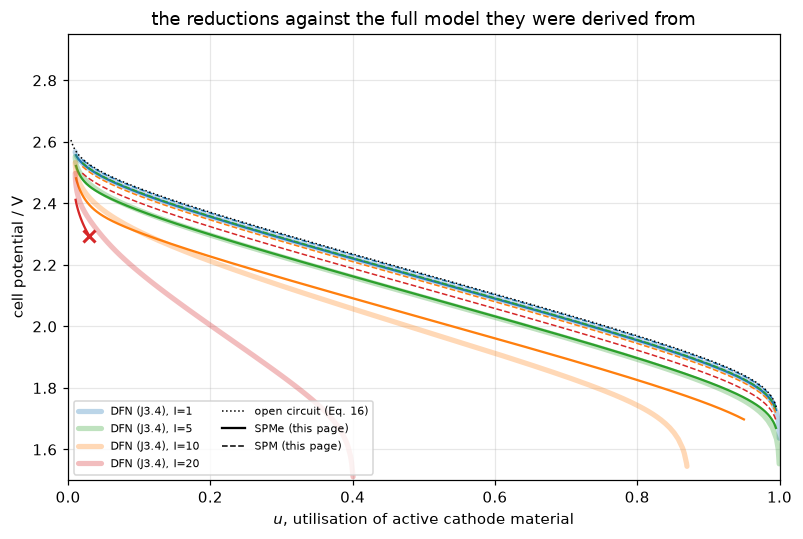

  I / A/m2     C_e  SPM RMS/mV  SPMe RMS/mV  SPMe valid to u
         1   0.015        12.1         0.05            0.995
         5   0.077        62.3         2.97            0.995
        10   0.153       159.8        47.50            0.950
        20   0.306       350.3          n/a            0.030

RMS over u in [0.05, min(0.85, DFN end)], deviation = V_reduced - V_DFN.
These four use the display solve (default DFN time step, SPMe n_t = 800); the
converged numbers the page reports come from the Validation sweep below.
At I = 20 the SPMe's electrolyte goes negative at u = 0.030 (x marker): outside its own conditions, as
predicted above, it refuses the regime rather than failing quietly.


In [8]:
cell = Cell(n_s=48, n_c=96)
SHOW_I = [1.0, 5.0, 10.0, 20.0]
runs_dfn = {}
for I in SHOW_I:
    t_mid = 0.45 * cell.t_full / I
    runs_dfn[I] = cell.march(I, record=[t_mid])

runs_spme = {}
for I in SHOW_I:
    u_top = min(0.995, float(runs_dfn[I][0][:, 0].max()) + 0.08)
    uu, v, rec, snaps = sp.v_curve(I, u_max=u_top,
                                   snap_at=[0.45 * T_FULL / I])
    ok = rec["c_min"] > 0.0                    # applicability: c must stay positive
    runs_spme[I] = (uu[ok], v[ok], rec, snaps, uu, v)

fig, ax = plt.subplots(figsize=(7.4, 5.0))
colors = {1.0: "tab:blue", 5.0: "tab:green", 10.0: "tab:orange", 20.0: "tab:red"}
for I, col in colors.items():
    tr = runs_dfn[I][0]
    o = np.argsort(tr[:, 0])
    ax.plot(tr[o, 0], tr[o, 1], color=col, lw=3.4, alpha=0.30,
            solid_capstyle="round", label=f"DFN (J3.4), I={I:g}")
    ug = np.linspace(0.02, 0.995, 400)
    ax.plot(ug, v_spm(ug, I), color=col, lw=1.0, ls="--")
    us, vs = runs_spme[I][0], runs_spme[I][1]
    ax.plot(us, vs, color=col, lw=1.5)
    if len(us) and us[-1] < 0.9 * tr[:, 0].max():
        ax.plot(us[-1], vs[-1], "x", color=col, ms=8, mew=2)
uu_oc = np.linspace(0.004, 0.996, 300)
ax.plot(uu_oc, U_ocp(uu_oc), "k:", lw=1.0, label="open circuit (Eq. 16)")
ax.plot([], [], "k-", lw=1.5, label="SPMe (this page)")
ax.plot([], [], "k--", lw=1.0, label="SPM (this page)")
ax.set(xlabel="$u$, utilisation of active cathode material",
       ylabel="cell potential / V", xlim=(0, 1.0), ylim=(1.5, 2.95),
       title="the reductions against the full model they were derived from")
ax.legend(fontsize=7.5, loc="lower left", ncol=2)
fig.tight_layout()
plt.show()

print(f"{'I / A/m2':>10}{'C_e':>8}{'SPM RMS/mV':>12}{'SPMe RMS/mV':>13}{'SPMe valid to u':>17}")
for I in SHOW_I:
    tr = runs_dfn[I][0]
    hi = min(0.85, float(tr[:, 0].max()) - 0.02)
    ug = np.linspace(0.05, hi, 121)
    v_dfn = np.interp(ug, tr[:, 0], tr[:, 1])
    e_spm = 1e3 * np.sqrt(np.mean((v_spm(ug, I) - v_dfn) ** 2))
    us, vs = runs_spme[I][0], runs_spme[I][1]
    if len(us) and us[-1] > ug[0]:
        m = ug <= us[-1]
        e_spme = 1e3 * np.sqrt(np.mean((np.interp(ug[m], us, vs) - v_dfn[m]) ** 2))
        txt = f"{e_spme:13.2f}"
    else:
        txt = f"{'n/a':>13}"
    u_lim = us[-1] if len(us) else 0.0
    print(f"{I:>10.0f}{Ce_doyle(I):>8.3f}{e_spm:>12.1f}{txt}{u_lim:>17.3f}")
print("\nRMS over u in [0.05, min(0.85, DFN end)], deviation = V_reduced - V_DFN.")
print("These four use the display solve (default DFN time step, SPMe n_t = 800); the")
print("converged numbers the page reports come from the Validation sweep below.")
print("At I = 20 the SPMe's electrolyte goes negative at u = "
      f"{runs_spme[20.0][0][-1]:.3f} (x marker): outside its own conditions, as")
print("predicted above, it refuses the regime rather than failing quietly.")

### What the electrolyte correction actually is

The SPMe's whole content beyond the SPM is the profile $\tilde c(x,t)$. Against
the DFN's electrolyte at mid-discharge: at $I=1$ the first-order profile is the
profile; at $I=5$ its shape is right but the linearisation strain is already
visible — the DFN's true profile is flatter where depletion raises the local
gradient.

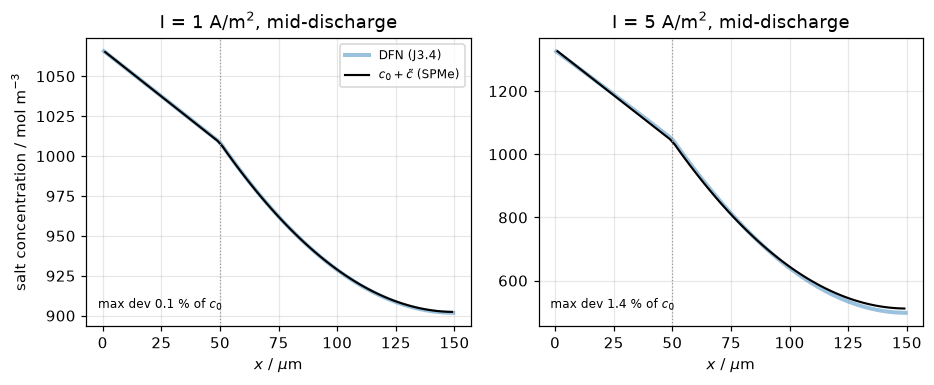

max profile deviation: 0.06 % of c_0 at I=1, 1.4 % at I=5


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8.6, 3.6), sharex=True)
for ax, I in zip(axes, [1.0, 5.0]):
    t_mid = 0.45 * cell.t_full / I
    snaps_dfn = runs_dfn[I][1]
    c_dfn = cell.unpack(snaps_dfn[t_mid])[0]
    c_spme = P["c_0"] + runs_spme[I][3][0.45 * T_FULL / I]
    ax.plot(1e6 * cell.x_c, c_dfn, color="tab:blue", lw=2.6, alpha=0.45,
            label="DFN (J3.4)")
    ax.plot(1e6 * sp.x_c, c_spme, "k-", lw=1.4, label=r"$c_0 + \tilde{c}$ (SPMe)")
    ax.axvline(1e6 * ds, color="0.6", lw=0.8, ls=":")
    ax.set(xlabel=r"$x$ / $\mu$m", title=f"I = {I:g} A/m$^2$, mid-discharge")
    dev = np.abs(np.interp(cell.x_c, sp.x_c, c_spme) - c_dfn).max() / P["c_0"]
    ax.text(0.03, 0.06, f"max dev {100*dev:.1f} % of $c_0$", transform=ax.transAxes,
            fontsize=8)
axes[0].set_ylabel("salt concentration / mol m$^{-3}$")
axes[0].legend(fontsize=8)
fig.tight_layout()
plt.show()
prof_dev = {}
for I in (1.0, 5.0):
    t_mid = 0.45 * cell.t_full / I
    c_dfn = cell.unpack(runs_dfn[I][1][t_mid])[0]
    c_spme = P["c_0"] + runs_spme[I][3][0.45 * T_FULL / I]
    prof_dev[I] = float(np.abs(np.interp(cell.x_c, sp.x_c, c_spme) - c_dfn).max()
                        / P["c_0"])
print(f"max profile deviation: {100*prof_dev[1.0]:.2f} % of c_0 at I=1, "
      f"{100*prof_dev[5.0]:.1f} % at I=5")

## Validation

Everything here is model-vs-model; the deviation convention is
**(reduced − full)**, reported in mV, with the full model being the J3.4 DFN
solve. Five checks, ordered by what they can catch.

1. **The paper's arithmetic** — Tables II and III recomputed from Table I
   (done above, under *The data*): 21/21 to printed precision, and the in-text
   $\mathcal{C}_e$ shown to be inconsistent with the paper's own table.
2. **An exact solution for the SPMe operator.** The quasi-steady correction is
   piecewise quadratic in closed form; the pymrm solve must land on it at
   $O(h^2)$.
3. **The asymptotic error scaling — the paper's central claim.** RMS voltage
   error against the DFN over a five-point current sweep: slope 1 for the SPM,
   slope $\approx 2$ for the SPMe as $\mathcal{C}_e\to0$. The sweep comes with
   a **mutation table** that measures what it can and cannot resolve: each
   correction term is mis-scaled or deleted in turn, and only the terms whose
   mutation collapses the exponent are actually tested by this page. Two of the
   four are; two are not, and the page says which.
4. **Structural conservation.** Salt in the SPMe integrator to machine
   precision, and the coulomb-counting identity on the DFN (Marquis et al.'s
   Eq. 32, $\bar c^1_{s,k}=0$, is exact at constant current).
5. **Numerical independence.** Grid and time step for the SPMe *at the sweep's
   lowest current*, where the signal is smallest; the DFN time step refined
   until the lowest sweep point stops moving; and the current below which the
   DFN integrator does not run at all.

A sixth thing this section deliberately does **not** do: test the parameter
set. The measured $\kappa$-sensitivity below quantifies that.

**A note on what the SPM's slope means.** On this cell $\kappa$ and $D$ are
constants and the first-order electrolyte perturbation is linear in $I$, so
*every* term the SPM omits is exactly proportional to $I$: its slope 1 is
structural and is not independent evidence. Only the SPMe slope is a test.

In [10]:
# ---- 2. exact solution for the SPMe operator --------------------------------
ratios = {}
for ns, nc in [(24, 48), (48, 96)]:
    s2 = SPMe(n_s=ns, n_c=nc)
    err = np.abs(s2.steady(1.0) - s2.steady_closed_form(1.0)).max()
    amp = np.ptp(s2.steady_closed_form(1.0))
    ratios[(ns, nc)] = err / amp
    print(f"2. steady SPMe vs closed-form quadratic, grid {ns}+{nc}: "
          f"max|dc|/amplitude = {err/amp:.2e}")
op_order = ratios[(24, 48)] / ratios[(48, 96)]
print(f"   error ratio under 2x refinement: {op_order:.2f}  (4.00 = clean O(h^2))")
print("   (the profile is independent of I up to scale - linearity - so I=1 suffices)")

2. steady SPMe vs closed-form quadratic, grid 24+48: max|dc|/amplitude = 3.53e-05
2. steady SPMe vs closed-form quadratic, grid 48+96: max|dc|/amplitude = 8.80e-06
   error ratio under 2x refinement: 4.02  (4.00 = clean O(h^2))
   (the profile is independent of I up to scale - linearity - so I=1 suffices)


 I / A/m2      C_e  SPM RMS/mV  SPMe RMS/mV   ratio
     0.25   0.0038       3.039      0.00242    1258
     0.50   0.0077       6.074      0.01012     600
     1.00   0.0153      12.139      0.04521     268
     2.00   0.0306      24.300      0.23220     105
     4.00   0.0613      49.240      1.51067      33

SPM: slope 1.00 over all five points (asymptotics: O(C_e), slope 1).
   That 1.00 is structural on this cell, not evidence: with constant kappa and D
   every term the SPM omits is exactly proportional to I.

SPMe: there is no single slope to quote. Local slopes, low to high current:
   2.07  2.16  2.36  2.70   (0.25->0.5, 0.5->1, 1->2, 2->4)
   three-point window fits:  [0.25,1] 2.11   [0.5,2] 2.26   [1,4] 2.53   all five: 2.31
   The exponent DRIFTS UPWARD with current, so a fitted slope is a statement
   about a window: it moves by 20 % across the three above. The asymptotic
   claim is the limit C_e -> 0, and the lowest local slope, 2.07, is the
   closest measurement of it 

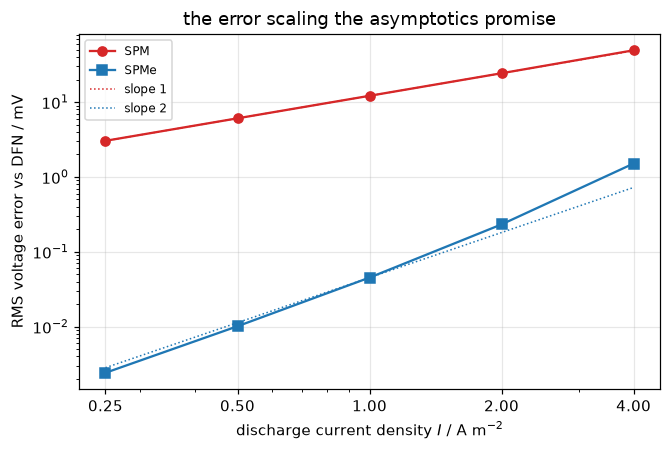

In [11]:
# ---- 3. the asymptotic error scaling ----------------------------------------
UGRID = np.linspace(0.05, 0.85, 161)
sweep_I = [0.25, 0.5, 1.0, 2.0, 4.0]
DT_SWEEP, NT_SWEEP = 0.0625, 3200     # converged settings; the ladder is check 5
cell_fine = Cell(n_s=48, n_c=96, dt_scale=DT_SWEEP)


def dfn_on_grid(tr, ugrid=UGRID):
    """np.interp CLAMPS outside its data: a march that stopped early would be
    extended as a flat voltage and reported as a huge 'model error' with no
    warning at all. Refuse instead - see the I = 0.125 study in check 5d."""
    if len(tr) == 0 or tr[:, 0].max() < ugrid.max() or tr[:, 0].min() > ugrid.min():
        got = f"[{tr[:, 0].min():.3f}, {tr[:, 0].max():.3f}]" if len(tr) else "empty"
        raise RuntimeError(
            f"the DFN march covers u = {got}, not the comparison window "
            f"[{ugrid.min():.3f}, {ugrid.max():.3f}]: np.interp would clamp and the "
            "reported error would be meaningless")
    return np.interp(ugrid, tr[:, 0], tr[:, 1])


err_spm, err_spme, v_dfn_sweep, spme_rec = {}, {}, {}, {}
for I in sweep_I:
    t_ref = cell_fine.t_full / I
    tr, _ = cell_fine.march(I, t_stop=(0.87 - P["u_0"]) * t_ref, max_steps=6000)
    v_dfn_sweep[I] = dfn_on_grid(tr)
    err_spm[I] = float(np.sqrt(np.mean((v_spm(UGRID, I) - v_dfn_sweep[I]) ** 2)))
    uu, v, rec, _ = sp.v_curve(I, u_max=0.87, n_t=NT_SWEEP)
    spme_rec[I] = (uu, rec)
    err_spme[I] = float(np.sqrt(np.mean((np.interp(UGRID, uu, v)
                                         - v_dfn_sweep[I]) ** 2)))

print(f"{'I / A/m2':>9}{'C_e':>9}{'SPM RMS/mV':>12}{'SPMe RMS/mV':>13}{'ratio':>8}")
for I in sweep_I:
    print(f"{I:>9.2f}{Ce_doyle(I):>9.4f}{1e3*err_spm[I]:>12.3f}"
          f"{1e3*err_spme[I]:>13.5f}{err_spm[I]/err_spme[I]:>8.0f}")

Iv = np.array(sweep_I)
es = np.array([err_spm[I] for I in sweep_I])
ee = np.array([err_spme[I] for I in sweep_I])


def fit_slope(Is, err):
    return float(np.polyfit(np.log(Is), np.log([err[I] for I in Is]), 1)[0])


slope_spm = float(np.polyfit(np.log(Iv), np.log(es), 1)[0])
slope_spme_all = float(np.polyfit(np.log(Iv), np.log(ee), 1)[0])
loc = np.log(ee[1:] / ee[:-1]) / np.log(Iv[1:] / Iv[:-1])
WINDOWS = [[0.25, 0.5, 1.0], [0.5, 1.0, 2.0], [1.0, 2.0, 4.0]]
win_fit = {tuple(w): fit_slope(w, err_spme) for w in WINDOWS}
slope_spme_mid = win_fit[(0.5, 1.0, 2.0)]
print(f"\nSPM: slope {slope_spm:.2f} over all five points (asymptotics: O(C_e), slope 1).")
print("   That 1.00 is structural on this cell, not evidence: with constant kappa and D")
print("   every term the SPM omits is exactly proportional to I.")
print(f"\nSPMe: there is no single slope to quote. Local slopes, low to high current:")
print("   " + "  ".join(f"{s:.2f}" for s in loc) + "   (0.25->0.5, 0.5->1, 1->2, 2->4)")
print("   three-point window fits:  " + "   ".join(
    f"[{w[0]:g},{w[-1]:g}] {win_fit[tuple(w)]:.2f}" for w in WINDOWS)
    + f"   all five: {slope_spme_all:.2f}")
print(f"   The exponent DRIFTS UPWARD with current, so a fitted slope is a statement")
print(f"   about a window: it moves by {100*(win_fit[(1.0,2.0,4.0)]/win_fit[(0.25,0.5,1.0)]-1):.0f} % "
      "across the three above. The asymptotic")
print(f"   claim is the limit C_e -> 0, and the lowest local slope, {loc[0]:.2f}, is the")
print("   closest measurement of it this sweep can make.")
cmin4 = (float(sp.steady(4.0).min()) + P["c_0"]) / P["c_0"]
print(f"   The drift is electrolyte depletion turning nonlinear (min c/c_0 = {cmin4:.2f}")
print("   at I = 4): higher-order terms enter and grow the error faster than C_e^2 -")
print("   still vanishing in the limit the theorem speaks about.")
print(f"   All five points use a DFN time step 16x tighter than the default and an SPMe")
print(f"   step of {NT_SWEEP} per discharge; check 5 shows both converged at I = 0.25,")
print("   the point where convergence is hardest and the signal smallest.")

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(Iv, 1e3 * es, "o-", color="tab:red", label="SPM")
ax.loglog(Iv, 1e3 * ee, "s-", color="tab:blue", label="SPMe")
ref = np.array([0.25, 4.0])
ax.loglog(ref, 1e3 * es[2] * ref / 1.0, ":", color="tab:red", lw=1,
          label="slope 1")
ax.loglog(ref, 1e3 * ee[2] * (ref / 1.0) ** 2, ":", color="tab:blue", lw=1,
          label="slope 2")
ax.set(xlabel="discharge current density $I$ / A m$^{-2}$",
       ylabel="RMS voltage error vs DFN / mV",
       title="the error scaling the asymptotics promise")
ax.set_xticks(Iv)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.xaxis.set_minor_formatter(plt.matplotlib.ticker.NullFormatter())
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

#### 3b. What the slope test resolves — and what it does not

A slope test is only as strong as the terms it can see. Each of the four
first-order corrections is now mis-scaled or deleted in turn, on the *same*
electrolyte solve and against the *same* DFN reference, so the table below
isolates the voltage assembly alone.

In [12]:
# ---- 3b. one correction term mutated at a time ------------------------------
MUT = [("baseline (canonical SPMe)", {}),
       ("ohmic delta_c/3 -> delta_c/2.7  (10 %)", {"ohm_div": 2.7}),
       ("concentration factor 2 -> 2.2  (10 %)", {"conc_fac": 2.2}),
       ("electrode-averaged exchange current deleted", {"use_pre_bar": False}),
       ("anode overpotential at c_0, not c(0)", {"anode_at_wall": False})]
mut_err = {}
for name, kw in MUT:
    e = {}
    for I in sweep_I:
        uu, rec = spme_rec[I]
        v = sp.voltage(uu, I, rec["c_wall"], rec["c_cath"], rec["pre_bar"], **kw)
        e[I] = float(np.sqrt(np.mean((np.interp(UGRID, uu, v) - v_dfn_sweep[I]) ** 2)))
    mut_err[name] = e

print(f"{'variant':>44}{'RMS(I=1)/mV':>13}{'x base':>8}{'fit[0.5,2]':>12}"
      f"{'local slopes':>26}")
for name, _ in MUT:
    e = mut_err[name]
    ev = np.array([e[I] for I in sweep_I])
    lm = np.log(ev[1:] / ev[:-1]) / np.log(Iv[1:] / Iv[:-1])
    print(f"{name:>44}{1e3*e[1.0]:>13.5f}{e[1.0]/err_spme[1.0]:>8.2f}"
          f"{fit_slope([0.5, 1.0, 2.0], e):>12.2f}"
          + "".join(f"{s:>6.2f}" for s in lm))

r_ohm = mut_err[MUT[1][0]][1.0] / err_spme[1.0]
r_con = mut_err[MUT[2][0]][1.0] / err_spme[1.0]
r_pre = mut_err[MUT[3][0]][1.0] / err_spme[1.0] - 1.0
r_ano = mut_err[MUT[4][0]][1.0] / err_spme[1.0] - 1.0
s_ano = fit_slope([0.5, 1.0, 2.0], mut_err[MUT[4][0]])
print(f"\nTwo of the four terms are resolved sharply. A 10 % error in the ohmic or the")
print(f"concentration coefficient multiplies the I = 1 error by {r_ohm:.1f}x and {r_con:.1f}x and")
print(f"collapses the exponent to ~1: the uncancelled O(C_e) remainder then dominates,")
print("which is exactly the failure mode the asymptotics predict. The other two are NOT")
print("resolved by this test on this cell:")
print(f"  * deleting the electrode-averaged exchange-current correction (their Eqs. 48n-o)")
print(f"    entirely changes the error by {100*r_pre:.2f} % and the exponent not at all. That is")
print(f"    itself a result - for a 1:1 salt at c_0 = {P['c_0']:.0f} against c_max = {P['c_max']:.0f} the")
print("    cathode average of the prefactor is indistinguishable from its value at c_0 -")
print("    but it means this page does NOT test that term: a sign error in it would pass;")
print(f"  * evaluating the anode overpotential at c_0 instead of c(0) changes the error by")
print(f"    {100*r_ano:.0f} % and leaves the exponent at {s_ano:.2f}, not 1: visible, not sharp.")
print("Read the sweep as verifying the ohmic and concentration corrections, and as")
print("bounding - not verifying - the exchange-current average and the anode term.")

                                     variant  RMS(I=1)/mV  x base  fit[0.5,2]              local slopes
                   baseline (canonical SPMe)      0.04521    1.00        2.26  2.07  2.16  2.36  2.70
      ohmic delta_c/3 -> delta_c/2.7  (10 %)      0.44412    9.82        0.89  0.99  0.96  0.83  0.42
       concentration factor 2 -> 2.2  (10 %)      0.67489   14.93        0.93  0.99  0.97  0.89  0.50
 electrode-averaged exchange current deleted      0.04522    1.00        2.26  2.07  2.16  2.36  2.70
        anode overpotential at c_0, not c(0)      0.04958    1.10        1.83  1.90  1.84  1.82  2.55

Two of the four terms are resolved sharply. A 10 % error in the ohmic or the
concentration coefficient multiplies the I = 1 error by 9.8x and 14.9x and
collapses the exponent to ~1: the uncancelled O(C_e) remainder then dominates,
which is exactly the failure mode the asymptotics predict. The other two are NOT
resolved by this test on this cell:
  * deleting the electrode-averaged e

#### 3c. What a *shared* parameter error does

The same sweep, with the one reconstructed input moved by its published
uncertainty. This measures the blind spot of every model-vs-model page:
parameters that enter both models identically cancel.

In [13]:
# ---- 3c. kappa is J3.4's reconstruction: how much of it survives the comparison
KAP_HI = 1.19 * KAPPA          # J3.4's two published routes to kappa differ by 19 %
cell_k = Cell(n_s=48, n_c=96, kappa=KAP_HI, dt_scale=DT_SWEEP)
tr_k, _ = cell_k.march(1.0, t_stop=(0.87 - P["u_0"]) * cell_k.t_full, max_steps=6000)
v_dfn_k = dfn_on_grid(tr_k)
uu, rec = spme_rec[1.0]
v_k = sp.voltage(uu, 1.0, rec["c_wall"], rec["c_cath"], rec["pre_bar"], kappa=KAP_HI)
err_spme_k = float(np.sqrt(np.mean((np.interp(UGRID, uu, v_k) - v_dfn_k) ** 2)))
kappa_shift_mV = 1e3 * float(np.mean(v_dfn_k - v_dfn_sweep[1.0]))
kappa_err_change = err_spme_k / err_spme[1.0] - 1.0
print(f"kappa = {KAPPA:.4f} S/m is J3.4's reconstruction; its two published routes")
print(f"disagree by 19 %. Raising it by 19 % moves the DFN discharge curve by "
      f"{kappa_shift_mV:+.2f} mV")
print(f"on average and changes the MEASURED SPMe error at I = 1 from "
      f"{1e3*err_spme[1.0]:.5f} to {1e3*err_spme_k:.5f} mV")
print(f"({100*kappa_err_change:+.0f} %) - against the {r_ohm:.1f}x that a 10 % error in the "
      "reduction's OWN ohmic")
print("coefficient produces. The parameter enters both models identically and cancels.")
print("That is what makes the measured error the reduction's own error; it is equally")
print("why nothing on this page can detect an error in kappa, U_ocp, k_2, sigma or i_0_1.")

kappa = 0.0485 S/m is J3.4's reconstruction; its two published routes
disagree by 19 %. Raising it by 19 % moves the DFN discharge curve by +0.83 mV
on average and changes the MEASURED SPMe error at I = 1 from 0.04521 to 0.04107 mV
(-9 %) - against the 9.8x that a 10 % error in the reduction's OWN ohmic
coefficient produces. The parameter enters both models identically and cancels.
That is what makes the measured error the reduction's own error; it is equally
why nothing on this page can detect an error in kappa, U_ocp, k_2, sigma or i_0_1.


In [14]:
# ---- 4. structural conservation ---------------------------------------------
_, _, rec1, _ = sp.v_curve(1.0, u_max=0.87)
salt_scale = P["c_0"] * float(np.sum(sp.eps * sp.dx))       # total salt in the cell
salt_drift = float(np.abs(rec1["salt"]).max()) / salt_scale
print(f"4. SPMe salt conservation: max |integral of eps*c_tilde| = "
      f"{salt_drift:.1e} of the cell's salt inventory ({len(rec1['t'])} steps)")

tr1 = runs_dfn[1.0][0]
u_cc = u_of_t(tr1[:, 2], 1.0)
coulomb_dev = float(np.abs(tr1[:, 0] - u_cc).max())
print(f"   DFN coulomb-counting identity: max |u - (u_0 + It/Q)| = {coulomb_dev:.1e}")
print("   (this is Marquis et al.'s Eq. 32 - the electrode-averaged solid")
print("    concentration has no first-order correction - holding exactly)")

4. SPMe salt conservation: max |integral of eps*c_tilde| = 4.5e-13 of the cell's salt inventory (800 steps)
   DFN coulomb-counting identity: max |u - (u_0 + It/Q)| = 6.7e-16
   (this is Marquis et al.'s Eq. 32 - the electrode-averaged solid
    concentration has no first-order correction - holding exactly)


In [15]:
# ---- 5. numerical independence ----------------------------------------------
# Everything is checked at I = 0.25, the sweep's lowest current: the signal there
# is 20x smaller than at I = 1, so that is where discretisation can contaminate
# the measurement, and it is the point that carries the low-end slope.
I_LOW = sweep_I[0]
print(f"5a. SPMe time step - measured RMS error vs the sweep's DFN reference (mV):")
dt_spread, dt_rel = 0.0, 0.0
for I_chk in (I_LOW, 1.0):
    row = []
    for n_t in (800, NT_SWEEP, 12800):
        uun, vn, _, _ = sp.v_curve(I_chk, u_max=0.87, n_t=n_t)
        row.append(float(np.sqrt(np.mean((np.interp(UGRID, uun, vn)
                                          - v_dfn_sweep[I_chk]) ** 2))))
    dt_spread = max(dt_spread, 1e3 * abs(row[2] - row[1]))
    dt_rel = max(dt_rel, abs(row[2] / row[1] - 1))
    print(f"    I = {I_chk:4.2f}:  n_t 800 -> {1e3*row[0]:.5f}   {NT_SWEEP} -> "
          f"{1e3*row[1]:.5f}   12800 -> {1e3*row[2]:.5f}"
          f"   (last refinement {100*abs(row[2]/row[1]-1):.1f} %)")

print("5b. SPMe grid - same quantity, same reference (mV):")
grid_spread, grid_rel = 0.0, 0.0
for I_chk in (I_LOW, 1.0):
    row = []
    for ns, nc in [(24, 48), (48, 96), (96, 192)]:
        s2 = SPMe(n_s=ns, n_c=nc)
        uun, vn, _, _ = s2.v_curve(I_chk, u_max=0.87, n_t=NT_SWEEP)
        row.append(float(np.sqrt(np.mean((np.interp(UGRID, uun, vn)
                                          - v_dfn_sweep[I_chk]) ** 2))))
    grid_spread = max(grid_spread, 1e3 * abs(row[2] - row[0]))
    grid_rel = max(grid_rel, abs(row[2] / row[0] - 1))
    print(f"    I = {I_chk:4.2f}:  24+48 -> {1e3*row[0]:.5f}   48+96 -> {1e3*row[1]:.5f}"
          f"   96+192 -> {1e3*row[2]:.5f}   (24+48 is what the sweep uses)")
worst_rel = max(dt_rel, grid_rel)
print(f"    Refining the SPMe step moves the measured error by at most "
      f"{100*dt_rel:.1f} %, and refining its")
print(f"    grid by at most {100*grid_rel:.1f} %, at either end of the sweep. The worst of "
      f"those, applied to")
print(f"    one sweep point alone, would move a local slope by "
      f"{np.log1p(worst_rel)/np.log(2.0):.2f} - so the exponents")
print(f"    below are resolved to about +-{np.log1p(worst_rel)/np.log(2.0):.2f}, against a "
      f"drift of {loc[3]-loc[0]:.2f} across the sweep.")

5a. SPMe time step - measured RMS error vs the sweep's DFN reference (mV):


    I = 0.25:  n_t 800 -> 0.00227   3200 -> 0.00242   12800 -> 0.00242   (last refinement 0.4 %)


    I = 1.00:  n_t 800 -> 0.04509   3200 -> 0.04521   12800 -> 0.04522   (last refinement 0.0 %)
5b. SPMe grid - same quantity, same reference (mV):


    I = 0.25:  24+48 -> 0.00242   48+96 -> 0.00246   96+192 -> 0.00247   (24+48 is what the sweep uses)


    I = 1.00:  24+48 -> 0.04521   48+96 -> 0.04552   96+192 -> 0.04559   (24+48 is what the sweep uses)
    Refining the SPMe step moves the measured error by at most 0.4 %, and refining its
    grid by at most 2.1 %, at either end of the sweep. The worst of those, applied to
    one sweep point alone, would move a local slope by 0.03 - so the exponents
    below are resolved to about +-0.03, against a drift of 0.64 across the sweep.


In [16]:
# ---- 5c. the DFN time step at the sweep's lowest current --------------------
uu, rec = spme_rec[I_LOW]
v_spme_low = np.interp(UGRID, uu, sp.voltage(uu, I_LOW, rec["c_wall"], rec["c_cath"],
                                             rec["pre_bar"]))
print(f"5c. DFN time step at I = {I_LOW}: apparent SPMe error as the step is refined")
ladder, prev = {}, None
for dts in (1.0, 0.25, DT_SWEEP, 0.25 * DT_SWEEP):
    if dts == DT_SWEEP:
        v_d, note = v_dfn_sweep[I_LOW], "   <- used in the sweep"
    else:
        c5 = Cell(n_s=48, n_c=96, dt_scale=dts)
        tr5, _ = c5.march(I_LOW, t_stop=(0.87 - P["u_0"]) * c5.t_full / I_LOW,
                          max_steps=20000)
        v_d, note = dfn_on_grid(tr5), ""
    ladder[dts] = 1e3 * float(np.sqrt(np.mean((v_spme_low - v_d) ** 2)))
    ch = "" if prev is None else f"  ({100*(ladder[dts]/prev-1):+5.1f} % vs the row above)"
    print(f"    dt_scale = {dts:7.5f}: {ladder[dts]:.5f} mV{ch}{note}")
    prev = ladder[dts]
dfn_dt_converged = abs(ladder[0.25 * DT_SWEEP] / ladder[DT_SWEEP] - 1)
print(f"    The step used in the sweep is converged to {100*dfn_dt_converged:.1f} % at the "
      "hardest point of the")
print(f"    sweep; the untightened default is {100*abs(ladder[1.0]/ladder[DT_SWEEP]-1):.0f} % "
      "off, which is why the sweep does not")
print("    use it. What the sweep measures is the model's error, not the integrator's.")

5c. DFN time step at I = 0.25: apparent SPMe error as the step is refined


    dt_scale = 1.00000: 0.00773 mV


    dt_scale = 0.25000: 0.00272 mV  (-64.8 % vs the row above)
    dt_scale = 0.06250: 0.00242 mV  (-11.3 % vs the row above)   <- used in the sweep


    dt_scale = 0.01562: 0.00240 mV  ( -0.8 % vs the row above)
    The step used in the sweep is converged to 0.8 % at the hardest point of the
    sweep; the untightened default is 220 % off, which is why the sweep does not
    use it. What the sweep measures is the model's error, not the integrator's.


In [17]:
# ---- 5d. the bottom of the sweep is set by the DFN, not by the SPMe ----------
print("5d. Below I = 0.25 the DFN does not run at all - at any time step:")
for dts in (1.0, 0.25, DT_SWEEP):
    c6 = Cell(n_s=48, n_c=96, dt_scale=dts)
    tr6, _ = c6.march(0.125, t_stop=(0.87 - P["u_0"]) * c6.t_full / 0.125,
                      max_steps=20000)
    print(f"    I = 0.125, dt_scale = {dts:7.5f}: {len(tr6):4d} steps, u reaches "
          f"{tr6[:, 0].max():.4f}  (u_0 = {P['u_0']:.3f})")
uu9, v9, _, _ = sp.v_curve(0.125, u_max=0.87, n_t=NT_SWEEP)
clamped = 1e3 * float(np.sqrt(np.mean((np.interp(UGRID, uu9, v9)
                                       - np.interp(UGRID, tr6[:, 0], tr6[:, 1])) ** 2)))
print("    The Newton step collapses at the first steps, so I = 0.25 is the integrator's")
print("    FLOOR, not its edge, and the sweep cannot be extended downward on this solver.")
try:
    dfn_on_grid(tr6)
    print("    !! the guard did not fire - this should not happen")
except RuntimeError as exc:
    print(f"    A bare np.interp would clamp this stub and report an SPMe 'error' of "
          f"{clamped:.0f} mV")
    print(f"    with no warning. dfn_on_grid refuses it instead:\n      {exc}")

5d. Below I = 0.25 the DFN does not run at all - at any time step:


    I = 0.125, dt_scale = 1.00000:   36 steps, u reaches 0.0101  (u_0 = 0.010)


    I = 0.125, dt_scale = 0.25000:   91 steps, u reaches 0.0100  (u_0 = 0.010)
    I = 0.125, dt_scale = 0.06250:    7 steps, u reaches 0.0100  (u_0 = 0.010)


    The Newton step collapses at the first steps, so I = 0.25 is the integrator's
    FLOOR, not its edge, and the sweep cannot be extended downward on this solver.
    A bare np.interp would clamp this stub and report an SPMe 'error' of 401 mV
    with no warning. dfn_on_grid refuses it instead:
      the DFN march covers u = [0.010, 0.010], not the comparison window [0.050, 0.850]: np.interp would clamp and the reported error would be meaningless


#### 6. The one restriction `bv_invert` carries, measured

The Reuse section below offers `bv_invert` to any model with Doyle's kinetics,
so the condition under which it is exact has to be stated and tested rather than
assumed. Writing $z=e^{\alpha f\eta'}$ turns Eq. 17 into a quadratic in $z$ only
when its two exponents are $+\alpha_a f\eta'$ and $-\alpha_c f\eta'$ with
$\alpha_a=\alpha_c$. This cell feeds the closed form back through Eq. 17 — at
Doyle's own symmetric pair, and at two asymmetric pairs a reader might plausibly
have.

In [18]:
# ---- 6. bv_invert is exact only for alpha_a = alpha_c ------------------------
def i_eq17_ab(eta_p, cs, pre, aa, ac):
    """Doyle Eq. 17 with the two transfer coefficients kept separate."""
    return pre * (cs * np.exp(aa * eta_p / RTF)
                  - (C_T - cs) * np.exp(-ac * eta_p / RTF))


CS_T = 0.30 * C_T                       # a mid-discharge surface concentration
PRE_T = PRE0
print("bv_invert fed back through Eq. 17 (eta' = the closed form's answer):")
print(f"{'alpha_a':>9}{'alpha_c':>9}{'i / A m-2':>12}{'eta_closed/mV':>15}"
      f"{'eta_true/mV':>13}{'i recovered / i asked':>23}")
BV_ASYM_WORST, BV_SYM_WORST = 0.0, 0.0
for aa, ac in [(0.5, 0.5), (0.3, 0.7), (0.4, 0.6)]:
    for i_t in (0.05, 0.5, 5.0):
        # the closed form knows only ONE alpha; a reuser would pass alpha_a
        B = i_t / PRE_T
        z = (B + np.sqrt(B * B + 4.0 * CS_T * (C_T - CS_T))) / (2.0 * CS_T)
        eta_closed = (RTF / aa) * np.log(z)
        eta_true = brentq(lambda e: i_eq17_ab(e, CS_T, PRE_T, aa, ac) - i_t, -3.0, 3.0)
        ratio = i_eq17_ab(eta_closed, CS_T, PRE_T, aa, ac) / i_t
        if aa == ac:
            BV_SYM_WORST = max(BV_SYM_WORST, abs(ratio - 1.0))
        else:
            BV_ASYM_WORST = max(BV_ASYM_WORST, abs(ratio - 1.0))
        print(f"{aa:>9.1f}{ac:>9.1f}{i_t:>12.2f}{1e3*eta_closed:>15.3f}"
              f"{1e3*eta_true:>13.3f}{ratio:>23.4f}")
print(f"\nAt alpha_a = alpha_c the closed form reproduces the requested current to "
      f"{BV_SYM_WORST:.1e}.")
print(f"At alpha_a != alpha_c it is wrong by up to {100*BV_ASYM_WORST:.0f} % in the "
      f"current - and silently: it\nreturns a finite, plausible overpotential. This "
      f"page's own cell is symmetric (alpha_a =\nalpha_c = "
      f"{P['alpha_a']:.1f}), so nothing above is affected; the restriction belongs "
      f"to the function, not to\nthe results.")

bv_invert fed back through Eq. 17 (eta' = the closed form's answer):
  alpha_a  alpha_c   i / A m-2  eta_closed/mV  eta_true/mV  i recovered / i asked
      0.5      0.5        0.05         27.252       27.252                 1.0000
      0.5      0.5        0.50         27.318       27.318                 1.0000
      0.5      0.5        5.00         27.978       27.978                 1.0000
      0.3      0.7        0.05         45.419       27.253              1892.3843
      0.3      0.7        0.50         45.530       27.331               190.2847
      0.3      0.7        5.00         46.630       28.118                20.0695
      0.4      0.6        0.05         34.065       27.252               837.6503
      0.4      0.6        0.50         34.147       27.324                84.7609
      0.4      0.6        5.00         34.973       28.045                 9.4699

At alpha_a = alpha_c the closed form reproduces the requested current to 5.5e-14.
At alpha_a != alpha_c it is 

## What pymrm adds

**The reduction and the full model in one consistent frame.** Marquis et al.
derive the SPMe for a two-porous-electrode cell and validate it against their
own DFN implementation with a parameter set whose property *functions* live in
cited codes, not in the paper. This page re-does the derivation's arithmetic
for the half-cell geometry (the foil needs no electrode averaging; the
$\delta_c/3$ ohmic factor survives) and tests the result against a full model
the gallery has already validated — same grid, same operators, same reviewed
parameter set, so the measured error is the *reduction's* error and nothing
else's. The measured scaling — slope 1.00 for the SPM over the whole sweep,
and for the SPMe a local exponent of 2.07 at the bottom of the sweep drifting
to 2.70 at the top (three-point window fits 2.11 / 2.26 / 2.53) — is their
central claim, reproduced on a chemistry they never ran. The page also
measures *which* of the four correction terms that test can resolve: two
sharply, two not at all.

**An a-priori verdict on the 1993 paper's own operating window.** Evaluating
all five conditions of Table VI for the Doyle cell says — before any
simulation — that the SPMe holds at a few A/m², is marginal at $I=10$
($\mathcal{C}_e = 0.15$, $\hat\kappa_e = 1.0$) and inapplicable at $I=20$,
where its own first-order profile predicts negative concentration at
$I \gtrsim 10$ A/m². That is exactly the transport-limited collapse Doyle,
Fuller & Newman describe at $I=20$, where the potential "drops sharply when
about 30 % of the cathode material is utilized" (their text, journal page
1529) — the physics the reduction warns it cannot carry. And two of the five
conditions are Doyle's own printed groups: $\mathcal{C}_e \equiv S_s$
(their Eq. 27) and the solid-diffusion condition $\equiv S_c$ (their Eq. 26),
so Doyle, Fuller & Newman had printed the deciding numbers themselves in 1993.

**A closed-form SPMe(S) for the half-cell.** The quasi-steady correction is a
piecewise quadratic with one conservation constant — an *entirely algebraic*
battery model that this page uses as an exact solution for the operator check.

**Honest limits.** With constant $\kappa$ and $D$, the SPMe's correction terms
here have exactly the right functional form, so its absolute accuracy
(sub-0.1 mV at $I=1$) flatters the method relative to a cell with
concentration-dependent properties — Marquis et al.'s own cell shows 3 mV at
1C. The scaling exponents, not the mV values, are the transferable result —
and the SPM's exponent of exactly 1 is structural on this cell rather than
evidence, because with constant properties every term it omits is exactly
proportional to $I$. The mutation table bounds the rest: the exchange-current
average and the anode concentration correction are *not* resolved by anything
on this page, and a 19 % error in the reconstructed $\kappa$ — the one input
J3.4 had to rebuild — changes the measured error by only 9 %, because a shared
parameter cancels. Nothing here tests the parameter set. And
their Table IV is *not* reproduced here: that would need $U_n$, $U_p$,
$D_e(c_e)$, $\kappa_e(c_e)$ from DUALFOIL/fastDFN, which the paper does not
print — a page for their cell would need those functions sourced and reviewed
first.

In [19]:
metrics = {
    "marquis_tables_checked": float(len(devs)),
    "marquis_tables_max_rel_dev": mq_max_dev,
    "ce_text_vs_recomputed_rel": ce_text_dev,
    "Ce_doyle_at_I10": Ce_doyle(10.0),
    "S_s_printed_1993": S_s_printed,
    "C_r_doyle_at_I10": C_r_doyle(10.0),
    "spme_steady_op_rel_err": ratios[(24, 48)],
    "spme_steady_op_refine_ratio": op_order,
    "rms_spm_I1_mV": 1e3 * err_spm[1.0],
    "rms_spme_I1_mV": 1e3 * err_spme[1.0],
    "rms_spm_I4_mV": 1e3 * err_spm[4.0],
    "rms_spme_I4_mV": 1e3 * err_spme[4.0],
    "slope_spm": slope_spm,
    # the SPMe exponent drifts with current, so every window is reported
    "slope_spme_local_lowest": float(loc[0]),
    "slope_spme_fit_I025_I1": win_fit[(0.25, 0.5, 1.0)],
    "slope_spme_fit_I05_I2": slope_spme_mid,
    "slope_spme_fit_I1_I4": win_fit[(1.0, 2.0, 4.0)],
    "slope_spme_all": slope_spme_all,
    "ratio_spm_over_spme_I1": err_spm[1.0] / err_spme[1.0],
    # what the sweep resolves (ratios, so CI-stable near 1)
    "mut_ohm_error_ratio_I1": r_ohm,
    "mut_conc_error_ratio_I1": r_con,
    "mut_exchange_avg_error_ratio_I1": 1.0 + r_pre,
    "mut_anode_error_ratio_I1": 1.0 + r_ano,
    "kappa_plus19pc_error_ratio_I1": 1.0 + kappa_err_change,
    "I_depletion_Am2": I_dep,
    "salt_conservation_spme": salt_drift,
    "coulomb_identity_dev": coulomb_dev,
    "profile_dev_I1_frac": prof_dev[1.0],
    "profile_dev_I5_frac": prof_dev[5.0],
    "spme_dt_spread_mV": dt_spread,
    "spme_grid_spread_mV": grid_spread,
    "dfn_dt_convergence_I025": dfn_dt_converged,
    # the restriction bv_invert carries (item 6)
    "bv_invert_symmetric_max_current_dev": BV_SYM_WORST,
    "bv_invert_asymmetric_max_current_dev": BV_ASYM_WORST,
}
report_agreement("J3.5", metrics)

Agreement metrics for J3.5:
  marquis_tables_checked               = 21
  marquis_tables_max_rel_dev           = 0.0012305
  ce_text_vs_recomputed_rel            = 0.17742
  Ce_doyle_at_I10                      = 0.15316
  S_s_printed_1993                     = 0.15
  C_r_doyle_at_I10                     = 9.9592e-05
  spme_steady_op_rel_err               = 3.5317e-05
  spme_steady_op_refine_ratio          = 4.0151
  rms_spm_I1_mV                        = 12.139
  rms_spme_I1_mV                       = 0.045211
  rms_spm_I4_mV                        = 49.24
  rms_spme_I4_mV                       = 1.5107
  slope_spm                            = 1.0036
  slope_spme_local_lowest              = 2.0664
  slope_spme_fit_I025_I1               = 2.1132
  slope_spme_fit_I05_I2                = 2.2603
  slope_spme_fit_I1_I4                 = 2.5312
  slope_spme_all                       = 2.3098
  ratio_spm_over_spme_I1               = 268.49
  mut_ohm_error_ratio_I1               = 9.8232
  mu

{'page': 'J3.5',
 'metrics': {'marquis_tables_checked': 21.0,
  'marquis_tables_max_rel_dev': 0.0012305457294596867,
  'ce_text_vs_recomputed_rel': 0.17742039478305183,
  'Ce_doyle_at_I10': 0.1531638990035208,
  'S_s_printed_1993': 0.15,
  'C_r_doyle_at_I10': 9.959154693557974e-05,
  'spme_steady_op_rel_err': 3.53165997159315e-05,
  'spme_steady_op_refine_ratio': 4.015067847395778,
  'rms_spm_I1_mV': 12.138691226494496,
  'rms_spme_I1_mV': 0.04521113697449786,
  'rms_spm_I4_mV': 49.23958506065582,
  'rms_spme_I4_mV': 1.510669180748151,
  'slope_spm': 1.0036208691844102,
  'slope_spme_local_lowest': 2.0663710396304538,
  'slope_spme_fit_I025_I1': 2.1131524585602697,
  'slope_spme_fit_I05_I2': 2.2602755317897536,
  'slope_spme_fit_I1_I4': 2.5311828760048947,
  'slope_spme_all': 2.309789240184018,
  'ratio_spm_over_spme_I1': 268.4889617649195,
  'mut_ohm_error_ratio_I1': 9.82319255712509,
  'mut_conc_error_ratio_I1': 14.927594552826745,
  'mut_exchange_avg_error_ratio_I1': 1.0001264116506

## Reuse

**The reduction pattern, not just the battery.** The SPMe construction —
solve the leading-order problem, freeze its fluxes, drive one *linear*
correction PDE with them, and collect the voltage (or any output) corrections
by averaging over the domain — applies wherever a fast transport process
coexists with a slow capacity: the `B1.1` pellet with slowly deactivating
catalyst, chromatography columns, thermal packs. The ingredients that carry
over: constant operators + one `splu` factorisation per transient; the known
leading-order flux imposed through the face arrays so conservation is
structural; and an exact quasi-steady solution to test the operator against.

**The applicability calculator.** `Ce_doyle`, `kappa_hat_doyle` and the
$c=0$ root-find cost microseconds and decide *before* any solve whether the
reduction may be used. Any reduced model worth shipping should travel with its
own version of these.

**The closed-form Butler–Volmer inversion, under one condition.** `bv_invert`
solves Doyle's Eq. 17 for the overpotential in closed form (a quadratic in
$e^{\alpha f\eta'}$, thanks to the $c_s$, $c_T - c_s$ asymmetric prefactors).
A model with that kinetics — including the J3.4 DFN itself, in a
preconditioner — can reuse it **provided $\alpha_a = \alpha_c$**, which is what
makes the substitution $z = e^{\alpha f\eta'}$ collapse Eq. 17 to a quadratic at
all. Doyle's cell has $\alpha_a = \alpha_c = 0.5$, so everything on this page is
inside the condition; a reader with an asymmetric pair is not, and gets no error
— only a wrong overpotential. Validation item 6 measures it: at
$\alpha_a=0.3$, $\alpha_c=0.7$ and at $0.4/0.6$ the closed form returns a
plausible finite overpotential whose current is out by up to an order of
magnitude; that cell prints the figures. `J3.1` derives
the same $\alpha$ condition for Doyle's Eq. 17 → Eq. 16/30 collapse; this page
had been advertising the function without it until 2026-08-02.

**What not to reuse.** The linearised electrolyte correction above the
$I = 10.2$ A/m² the page computes for this cell — where the first-order
profile itself reaches zero concentration, which is exactly where it dies — and
the constant-$\kappa$ ohmic term for any electrolyte whose conductivity
actually varies: there, use Marquis et al.'s Eqs. 40 with the full
$\kappa_e(c_e)$, or stay with the DFN.